# Understing Parameter Importance in Sensitivity Analysis (DRAFT)

## 0. Goal

(Warning: this is a work in progress and is full of typos. Hopefully the code runs
smoothly.)

The purpose of this notebook is to present and give a practical example of the concept
of **parameter importance** in sensitivity analysis due to input uncertainty. We begin 
by describing how such an issue arises in practice, why the rocket designer is faced
with an important decision, and how the parameter importance tool we have developed 
helps him taking a rational approach to such decision.

In order to focus on parameter importance, we have hidden important but
technical details behind two abstractions:

- The "stochastic_simulation" function in the "sensitivity_analysis_utils.py" module
abstracts the process of sampling parameters and obtaining flight variables for 
analysis. Indeed, the dispersion_analysis original notebook already teaches us how to
do it.

- The "TargetSensitivityModel" class in the "sensitivity_model.py" module abstracts the
mathematics and statistics computations. To better understand what is being done, check
the technical document. 

This notebook focus on getting things done. If you wish to understand why things work
(if they indeed work), check the technical reference.

Reference:

https://drive.google.com/file/d/1mqpIE6YJQSiCdj1S1uxatDrSMVbIvMqi/view?usp=sharing

## 1. Setup

Before starting the relevant discussion, let us get the setup out of the way.

### Download data files if using Google Colab


As usual, we download the files required to perform the Monte Carlo simulations.

In [2]:
!curl -o dispersion_analysis_inputs/Cd_PowerOff.csv --create-dirs https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/docs/notebooks/dispersion_analysis/dispersion_analysis_inputs/Cd_PowerOff.csv
!curl -o dispersion_analysis_inputs/Cd_PowerOn.csv --create-dirs https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/docs/notebooks/dispersion_analysis/dispersion_analysis_inputs/Cd_PowerOn.csv
!curl -o dispersion_analysis_inputs/LASC2019_reanalysis.nc --create-dirs https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/docs/notebooks/dispersion_analysis/dispersion_analysis_inputs/LASC2019_reanalysis.nc
!curl -o dispersion_analysis_inputs/thrustCurve.csv --create-dirs https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/docs/notebooks/dispersion_analysis/dispersion_analysis_inputs/thrustCurve.csv
!curl -o dispersion_analysis_inputs/Valetudo_basemap_final.jpg --create-dirs https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/docs/notebooks/dispersion_analysis/dispersion_analysis_inputs/Valetudo_basemap_final.jpg
!mkdir -p dispersion_analysis_outputs

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100  1672  100  1672    0     0   4963      0 --:--:-- --:--:-- --:--:--  4961
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1666  100  1666    0     0   5506      0 --:--:-- --:--:-- --:--:--  5516
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  472k  100  472k    0     0   847k      0 --:--:-- --:--:-- --:--:--  846k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  2849  100  2849    0     0   7017      0 --:--:-- --:--:-- --:--:--  7034
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  347k  100  347k    0     0   741k      0 --:--:

### Install and Load Necessary Libraries

Along with the rocketpy, we install libraries that facilitate the parameter
importance analysis. Most of these libraries are used in the "sensitivity_model.py" 
and "sensitivity_analysis_utils.py" files. We emphasize here that these libraries are a
mere convenience for implementation and rapid prototyping. 
If the idea is indeed worthwhile, many of these dependencies can be droped and adjusted
to rocketpy requirements.

In [3]:
!pip install --quiet rocketpy pandas prettytable statsmodels tqdm

We now load the modules necessary for the analysis.

In [4]:
# Sampling abstraction
from sensitivity_analysis_utils import stochastic_simulation

# Math/Stats abstraction
from sensitivity_model import TargetSensivityModel

# Other libraries
import numpy as np

%config InlineBackend.figure_formats = ['svg']
import matplotlib as mpl
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

%matplotlib inline
mpl.rcParams["figure.figsize"] = [8, 5]
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["font.size"] = 14
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["figure.titlesize"] = 14

To guarantee reproducibility, we fix the random seed that will be used in the stochastic
simulators

In [5]:
random_seed = 42

## 2. Understanding the problem


Consider a rocket designer that must accurately predict the rocket's apogee and landing 
point for competition purposes. His rocket is mostly built so that he has most of its 
parameters stablished and he is using RocketPy to obtain the variables. The parameters 
that he specifies in the simulation, called **nominal parameters**, are used as input in 
RocketPy and generate a trajectory called **nominal trajectory**. He then happily 
analyze the nominal trajectory, checking if apogee and landing point satisfies his
required constraints, and takes a decision based on this analysis.

**There is a catch, however.** His nominal parameters come from real measurements, and
therefore come with instrumental errors. For instance, he might specify that his rocket
has total mass of $10$ kg but, if his balance has a precision of $10^{-2}$ kg, then we
expect the true mass of the rocket to fluctuate around $10$ kg in a scale of $10^{-2}$ kg.
At first glance, we might think that this is neglectable. Remember, however, that errors
accumulate, and since we have many parameters, most of them having precision errors, the
total error in the end starts to become relevant.

Due to this input parameter error, even if RocketPy was a perfect simulator of reality,
we would observe a deviation from the observed trajectory and the nominal trajetory.

In order to better understand the description above, let us do some coding and visualize
the concepts.

### 2.1 Nominal Parameters and Nominal Uncertainty

The nominal parameters are the parameters that the rocket designer would use in his simulation.
The dictionary below defines the nominal stochastic parameters. The dictionary keys
represent the parameters that are used in the simulation, such as rocket mass, impulse,
burn_time and so on. Each dictionary has a key that is also a dictionary! This dictionary
for each parameter has two keys, "mean" and "sd". The "mean" key contains a numeric value
which is de facto the nominal parameter value. In the example above, it would be the
$10$ kg for the rocket mass. The "sd" key contains a numeric value referencing the
instrument precision as a standard deviation. In the example above, the value would be
$10^{-2}$.

TL;DR:

- The keys are the parameters and their values are dictionaries
- The dictionary within has a "mean" key whose value defines the nominal parameter value
- The dictionary within has a "sd" key whose value defines the nominal parameter 
uncertainty

In [6]:
nominal_stochastic_parameters = {
    # Mass Details
    # Rocket's dry mass without motor (kg) and its uncertainty (standard deviation)
    "rocket_mass": {"mean": 7.257, "sd": 0.001},
    # Rocket's inertia moment perpendicular to its axis (kg*m^2)
    "rocket_inertia_11": {"mean": 3.675, "sd": 0.03675},
    # Rocket's inertia moment relative to its axis (kg*m^2)
    "rocket_inertia_33": {"mean": 0.007, "sd": 0.00007},
    # Motors's dry mass without propellant (kg) and its uncertainty (standard deviation)
    "motor_dry_mass": {"mean": 1.000, "sd": 0.001},
    # Motor's dry inertia moment perpendicular to its axis (kg*m^2)
    "motor_inertia_11": {"mean": 1.675, "sd": 0.01675},
    # Motors's dry inertia moment relative to its axis (kg*m^2)
    "motor_inertia_33": {"mean": 0.003, "sd": 0.00003},
    # Distance between rocket's center of dry mass and motor's center of dry mass (m)
    "motor_dry_mass_position": {"mean": 0.5, "sd": 0.001},
    # Propulsion Details - run help(SolidMotor) for more information
    # Motor total impulse (N*s)
    "impulse": {"mean": 1440.15, "sd": 35.3},
    # Motor burn out time (s)
    "burn_time": {"mean": 5.274, "sd": 1},
    # Motor's nozzle radius (m)
    "nozzle_radius": {"mean": 21.642 / 1000, "sd": 0.5 / 1000},
    # Motor's nozzle throat radius (m)
    "throat_radius": {"mean": 8 / 1000, "sd": 0.5 / 1000},
    # Motor's grain separation (axial distance between two grains) (m)
    "grain_separation": {"mean": 6 / 1000, "sd": 1 / 1000},
    # Motor's grain density (kg/m^3)
    "grain_density": {"mean": 1707, "sd": 50},
    # Motor's grain outer radius (m)
    "grain_outer_radius": {"mean": 21.4 / 1000, "sd": 0.375 / 1000},
    # Motor's grain inner radius (m)
    "grain_initial_inner_radius": {"mean": 9.65 / 1000, "sd": 0.375 / 1000},
    # Motor's grain height (m)
    "grain_initial_height": {"mean": 120 / 1000, "sd": 1 / 1000},
    # Aerodynamic Details - run help(Rocket) for more information
    # Rocket's radius (kg*m^2)
    "radius": {"mean": 40.45 / 1000, "sd": 0.001},
    # Distance between rocket's center of dry mass and nozzle exit plane (m) (negative)
    "nozzle_position": {"mean": -1.024, "sd": 0.001},
    # Distance between rocket's center of dry mass and and center of propellant mass (m) (negative)
    "grains_center_of_mass_position": {"mean": -0.571, "sd": 0.001},
    # Multiplier for rocket's drag curve. Usually has a mean value of 1 and a uncertainty of 5% to 10%
    "power_off_drag": {"mean": 0.9081 / 1.05, "sd": 0.033},
    # Multiplier for rocket's drag curve. Usually has a mean value of 1 and a uncertainty of 5% to 10%
    "power_on_drag": {"mean": 0.9081 / 1.05, "sd": 0.033},
    # Rocket's nose cone length (m)
    "nose_length": {"mean": 0.274, "sd": 0.001},
    # Axial distance between rocket's center of dry mass and nearest point in its nose cone (m)
    "nose_distance_to_CM": {"mean": 1.134, "sd": 0.001},
    # Fin span (m)
    "fin_span": {"mean": 0.077, "sd": 0.0005},
    # Fin root chord (m)
    "fin_root_chord": {"mean": 0.058, "sd": 0.0005},
    # Fin tip chord (m)
    "fin_tip_chord": {"mean": 0.018, "sd": 0.0005},
    # Axial distance between rocket's center of dry mass and nearest point in its fin (m)
    "fin_distance_to_CM": {"mean": -0.906, "sd": 0.001},
    # Launch and Environment Details - run help(Environment) and help(Flight) for more information
    # Launch rail inclination angle relative to the horizontal plane (degrees)
    "inclination": {"mean": 84.7, "sd": 1},
    # Launch rail heading relative to north (degrees)
    "heading": {"mean": 53, "sd": 2},
    # Launch rail length (m)
    "rail_length": {"mean": 5.7, "sd": 0.0005},
    # Parachute Details - run help(Rocket) for more information
    # Drag coefficient times reference area for the drogue chute (m^2)
    "cd_s_drogue": {"mean": 0.349 * 1.3, "sd": 0.07},
    # Time delay between parachute ejection signal is detected and parachute is inflated (s)
    "lag_rec": {"mean": 1, "sd": 0.5},
    # Electronic Systems Details - run help(Rocket) for more information
    # Time delay between sensor signal is received and ejection signal is fired (s)
    "lag_se": {"mean": 0.73, "sd": 0.16},
}

Not all parameters have uncertainty attached to them, hence the name "stochastic" for
those who have. The non-stochastic parameters are hidden inside the abstractions we
discussed. They are the same parameters specified in the dispersion analysis
original notebook, which are based on the Valetudo Rocket.

The cell below performs the simulation so that we can better understand 
the problem. (Wait a bit, it might take a while)

In [7]:
simulation_info = stochastic_simulation(
    nominal_stochastic_parameters, number_of_simulations=100, random_seed=random_seed
)

100%|██████████| 100/100 [01:19<00:00,  1.26it/s]


### 2.2 Nominal Trajectory, Simulated Trajectory and Observed Trajectory

The cell below displays the **nominal trajectory** as the solid red line. The dashed
black lines represent the **dispersion trajectories.** The idea is that one of the black
lines actually is the one that the rocket designer should be analysing. However, since he can
not know the true value of the parameters but only the nominal, what he can do is to
perform sensitivity analysis to understand what are the factors that explain why the
black curve is deviating from the red one.

**NOTE** The black trajectories are not the **observed trajectory.** The reason is
simple: RocketPy is a great but not perfect simulator (no one is!). Hence, one of these
black lines would be the best approximation to the observed trajectory, and it is why,
ideally, would be the one to analyze.

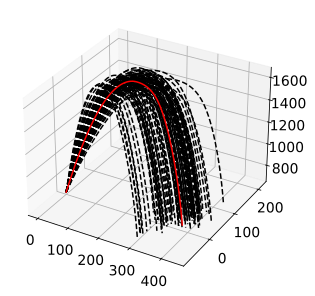

In [8]:
fig = plt.figure()
ax = plt.axes(projection="3d")
number_of_simulations = 100

# Nominal flight

for sim_number in range(1, 101):
    x = simulation_info.trajectories_df.loc[:, f"Sim_{sim_number}_Flight_x"]
    y = simulation_info.trajectories_df.loc[:, f"Sim_{sim_number}_Flight_y"]
    z = simulation_info.trajectories_df.loc[:, f"Sim_{sim_number}_Flight_z"]
    ax.plot(x, y, z, "black", linestyle="dashed")

nominal_x = simulation_info.trajectories_df.loc[:, "nominal_Flight_x"]
nominal_y = simulation_info.trajectories_df.loc[:, "nominal_Flight_y"]
nominal_z = simulation_info.trajectories_df.loc[:, "nominal_Flight_z"]
ax.plot(nominal_x, nominal_y, nominal_z, "red")

plt.show()

## 3. Framing the question and Parameter Importance
### 3.1 Framing the question

As examplified above, the rocket designer should not take the nominal trajectory at face value.
If he wishes to accurately predict the apogee and landing point, he should use his 
knowledge of the precision of each parameter and incorporate it into his analysis. 
But how can he do it?

The answer is quite obvious: enhance your instruments precisions. If the uncertainty on
the input parameters is reduced, so is the uncertainty on the target variables (apogee 
and landing point). But this obvious solution is just to broad. How much should the
precision increase? Moreover, does he have to measure *everything* with higher
precision?

Moreover, there are many, many parameters that go into a rocket simulator. Imagine that 
he has a fixed budget and needs to choose which instrument to buy. This implies that he 
can only increase the precision for a few parameters. How can he make such a choice?

In order to answer that question, he has to answer another question: **How much would the
variability of my target variables reduce if I measured this parameter with higher
precision?**

This is the key question to which we provide a practical solution.


### 3.2 Parameter Importance

The last question proposed above can be stated mathematically: **How much would the 
variance of the target variable decrease had we measure the parameter with certainty?**

Let $Y$ be the target variable, say the apogee, and assume we have $p$ input parameters.
Skipping the mathematics and statistics details behind it, the formula for the variance 
of $Y$ as a function of the nominal parameters and nominal standard deviations is given 
by

$$ Var(Y) = \sigma_{\epsilon}^2 + \sum_{j = 1}^p \sigma_j^2\beta_j^2 \quad.$$

The term $\sigma_{\epsilon}^2$ is the Linear Approximation Error (LAE) and represents,
*in some sense,* how reliable is our approach. The term $\sigma_j$ represents the
nominal standard deviation for the $j$-th parameter. For example, if "rocket_mass" is
the first nominal parameter, then we have $\sigma_1 = 0.001$. 

Finally, in easy terms, $\beta_j$ is the linear coefficient that tells us how much $Y$ 
varies when we vary one unit of the $j$-th parameter from its nominal value. 
We will see a more practical interpretation below.

The dependency of $Var(Y)$ on the $j$-th parameter is $\sigma_j^2\beta_j^2$. If we could
make $\sigma_j = 0$, meaning that we measure $j$ with perfect precision, then the
variance of $Var(Y)$ would reduce exactly in $\sigma_j^2\beta_j^2$. Normalizing by the
total variance and multiplying by $100$, we get, in percentage, how much the variance of 
$Y$ would decrease if we bough the perfect instrument to know the exact value of
parameter $j$.

Therefore, we define parameter importance as exactly the quantity described above.
Mathematically, Importance of the $j$-th parameter, $I(j)$, is defined as

$$
I(j) = 100 \times \frac{\sigma_j^2\beta_j^2}{\sigma_{\epsilon}^2 + \sum_{k = 1}^p \sigma_k^2\beta_k^2}.
$$

## 4. PRACTICE with parameter importance
### 4.1 Fitting the model for the apogee
When you open a jupyter notebook, you surely hope it is not as verbose as this notebook.

Lots of text + math + no code = alt + F4, I get it.

So, before you give up, let us quench your thirst for code and practice, let us use 
parameter importance to get results.

We begin by fitting a TargetSensitivityModel to our simulation results. This class hides
the mathematical details and wraps the parameter importance in a nice table for you.
We begin by considering the apogee.

In [9]:
sensitivity_model = TargetSensivityModel(["apogee"])
sensitivity_model.fit(simulation_info)

Fitting the model returns no information. To actually get the information, call the
summary method.

In [10]:
sensitivity_model.summary()

+----------------------------------------------------------------------------------------------------------------+
|                                                 Summary apogee                                                 |
+--------------------------------+----------------+--------------+------------+------------------------+---------+
|           Parameter            | Importance (%) | Nominal mean | Nominal sd | Regression Coefficient | p-value |
+--------------------------------+----------------+--------------+------------+------------------------+---------+
|            impulse             |    73.1401     |   1440.15    |    35.3    |         1.0312         |   0.0   |
|           burn_time            |     18.191     |    5.274     |     1      |        -18.1535        |   0.0   |
|             radius             |     4.3256     |    0.0404    |   0.001    |       -8852.2842       |   0.0   |
|       grain_outer_radius       |     1.3275     |    0.0214    |   0.0004   | 

### 4.2 Interpreting the summary table
The summary method prints a somewhat long table. Be sure to visualize it completely!
Let us interpret it

1. The first column presents the parameters names as specified in the code.
**The parameters are ordered according to importance.** This means that the first
parameter is the most important, and so on. One very special row is the one containing
the "Linear Approx. Error (LAE)". Briefly, this can be used to verify if the model is
trustworthy. Ideally, its importance should be low.

2. The second column is the importance as defined previously. The most important parameter
to explain the variability of the apogee is the impulse, and its value approximately
$73.14$%. This basically means that $73.14$% of the variance of the apogee is due to our
imprecision when we specify the impulse. The bottom of the table shows that the apogee
variance is $1811.61$. If we reduced its nominal standard deviation to $0$, we expect
the variance to drop to $486.5971$, a great difference! Check the cell below.

3. The third and fourth columns are the nominal value of the parameter and the nominal
standard deviation. We have already discussed this in length.

4. The fifth and sixth columns are the regression parameter and p-value for the 
$t$-test, respectively. Be very careful with these measures, **do not take them at face
value.** Do not think that, if $\beta_j$ is big, then the variable importance. There is
a reason why variable importace is defined as another quantity, use it.

5. Below the table (this needs to go *above* the table, I just did not find a way to do it
prettly!) we have the nominal value of the apogee, its variance and a prediction
interval. The narrower the interval, the better. In order to make it narrow, we have
to reduce the standard deviation of the parameters, as has been discussed at length.

In [11]:
impulse_importance = sensitivity_model.info["apogee"]["importance"]["impulse"]
apogee_variance = np.power(sensitivity_model.info["apogee"]["sd"], 2)
predicted_variance_drop = apogee_variance * (1 - (impulse_importance / 100))
print(f"Impulse Importance: {round(impulse_importance, 4)} %")
print(f"Apogee variance: {round(apogee_variance, 4)}")
print(
    f"Expected apogee variance if we knew the impulse value with certainty: {round(predicted_variance_drop, 4)}"
)

Impulse Importance: 73.1401 %
Apogee variance: 1811.6129
Expected apogee variance if we knew the impulse value with certainty: 486.5971


#### 4.3 Fitting the model for the impact point.

Let us fit the model for the impact point position x and y and compare
to the apogee!

In [12]:
sensitivity_model = TargetSensivityModel(["x_impact", "y_impact"])
sensitivity_model.fit(simulation_info)
sensitivity_model.summary()

+----------------------------------------------------------------------------------------------------------------+
|                                                Summary x_impact                                                |
+--------------------------------+----------------+--------------+------------+------------------------+---------+
|           Parameter            | Importance (%) | Nominal mean | Nominal sd | Regression Coefficient | p-value |
+--------------------------------+----------------+--------------+------------+------------------------+---------+
|          inclination           |    61.0034     |     84.7     |     1      |        -34.2061        |   0.0   |
|            impulse             |    15.9667     |   1440.15    |    35.3    |         0.4957         |   0.0   |
|           burn_time            |    10.0851     |    5.274     |     1      |        -13.9081        |   0.0   |
|          cd_s_drogue           |     8.6239     |    0.4537    |    0.07    | 

**Note**: there are two tables there. Be sure to scroll to see everything.

Notice that the most important parameter now is the inclination! You surely must be
thinking: should the importance order always be the same? The answer is: **no!**. The
importance of each parameter depends on the variable we are analyzing, and it makes
perfect sense! Indeed, the example above is **the best** proof of that.

Indeed, recall what is the inclination parameter, written in lucid comment in the
nominal_stochastic_parameters cell:

"# Launch rail inclination angle relative to the horizontal plane (degrees)"

Now think really hard about it. If we are uncertain about the launch angle in the
horizontal plane, then that creates an uncertainty, and hence variability,
in the landing point $x$ and $y$. However, the apogee is a measure on $z$, a coordinate
**orthogonal** to that plane. Hence, the apogee shouldn't depend a lot on it (it 
depends because of wind and stuff), but the landing point should depend a lot on it.

Therefore, the parameter importance is totally aligned with our logical thinking in 
this case.

### 4.4 Predicting variance reduction

In subsection 4.2, we saw that the variance for the apogee is $1811.6129$. What would happen if we made the nominal sd
of the impulse $0$, i.e. we knew the impulse with certainty without changing, then we
predict that the variance would reduce to something close to $486.5971$, hence giving a 
tighter and more accurate confidence interval.

That is what the math says. Let us see what the code says! First, we change the nominal
standard deviation of the impulse, then we simulate the trajectories again keeping
everything else as it was, and fit the sensitivity model again for the apogee.

In [13]:
# Changing the nominal sd of the impulse to zero to mimic perfect precision
nominal_stochastic_parameters["impulse"]["sd"] = 0

# Simulate things again
simulation_info = stochastic_simulation(
    nominal_stochastic_parameters, number_of_simulations=100, random_seed=random_seed
)

100%|██████████| 100/100 [01:15<00:00,  1.32it/s]


In [14]:
sensitivity_model = TargetSensivityModel(["apogee"])
sensitivity_model.fit(simulation_info)
sensitivity_model.summary()

+----------------------------------------------------------------------------------------------------------------+
|                                                 Summary apogee                                                 |
+--------------------------------+----------------+--------------+------------+------------------------+---------+
|           Parameter            | Importance (%) | Nominal mean | Nominal sd | Regression Coefficient | p-value |
+--------------------------------+----------------+--------------+------------+------------------------+---------+
|           burn_time            |     68.287     |    5.274     |     1      |        -18.2744        |   0.0   |
|             radius             |     15.923     |    0.0404    |   0.001    |       -8824.4426       |   0.0   |
|       grain_outer_radius       |     4.8162     |    0.0214    |   0.0004   |      -12941.8511       |   0.0   |
|         power_on_drag          |     4.4282     |    0.8649    |   0.033    | 

In [15]:
impulse_importance = sensitivity_model.info["apogee"]["importance"]["impulse"]
apogee_variance = np.power(sensitivity_model.info["apogee"]["sd"], 2)
predicted_variance_drop = apogee_variance * (1 - (impulse_importance / 100))
print(f"New Impulse Importance: {round(impulse_importance, 4)} %")
print(f"New Apogee variance: {round(apogee_variance, 4)}")

New Impulse Importance: 0.0 %
New Apogee variance: 489.046


The calculated variance is now $489.046$, very close to the predicted value of 
$486.5971$! This makes perfect sense since the variance is estimated with a finite sample
(n = $100$), so we would never get the number exactly right. Moreover, it makes perfect
sense that the new importance is $0$%. The reason is the following: the importance
of a parameter is how much it explains, in percentage, of the variability in $Y$ because
of its own variability. If we know, for certain, the value of the impulse, then there is
no variability. Hence, the new variability of $Y$ is not due to the impulse but rather
because of other parameters!

In a nutshell, if we know the value of the impulse for certain, then it is no longer
relevant in sensitivity analysis!

Notice now how burn_time become the most important parameter. Its percentage increased,
does it make sense? Yes, it does. The percentage is calculated with respect to the
current variance of $Y$. Previously, its importance was $18.191$ %. This means that it
explained $18.191$ % of the previous variance, $1811.6129$. Now, the variance has 
decreased because the impulse is known, and now the burn_time explains $68.287$ % of the 
new variance, which is $478.046$%.

### 5. PFAQ (Predicted Frequently Asked Question)

Surely, many questions might have arisen. I will try to predict and answer here some of
them.

Q1) You said that the coefficient $\beta_j$ measures the variation on $Y$ due to 
variations of the $j$-th parameter. Why not just use $\beta_j$ as the parameter
importance?

A1) At first glance, it might seem that the coefficient $\beta_j$ is exactly what we want.
Indeed, it is a measure of how much $Y$ variates with the $j$-th parameter. However,
notice that $Var(Y)$ depends both on $\beta_j$ and $\sigma_j$. The reason can be 
understood in the following example: the apogee is estimated as $5$ Km and assume that 
$\beta_j = 10$ Km. It might seem that the parameter $j$ is extremely important, and even
that the value of $\beta_j$ is it self unrealistic. However, we must take into account
the variation of the $j$-th parameter itself. Suppose that the standard deviation is
only $\sigma_j = 0.0001$ Km. Then, Albeit a unit of variation of $j$ causes $Y$ to vary $10$ 
Km, what really happens is that $j$ just varies very very little. In fact, the $j$-th
parameter is expected to vary by, at most, $0.0003$Km units from its nominal value, so, 
even in some of the most extreme case, the maximum variation on $Y$ due to the 
uncertainty on the value of the $j$-th parameter would be $10 \times 0.0003 = 0.003$ Km,
or $3$ meters. **This show that taking the regression parameter at face value is
misleading!!!**

Q2) Okay, but why $\sigma_j^2\beta_j^2$?

A2) First of all, because they are the terms that appear in the variance equation. But,
if you *really* want to understand why, it is because $\sigma_j\beta_j$ is the coefficient
of variation of $Y$ due to one unit of variation in the $j$-th parameter relative to
its nominal value **in the normalized scale**. In order to truly compare one parameter
to each other, you have to put all of them in the same scale. For more details, check
the technical document. 

Q3) In practice, it is impossible to have $\sigma_j = 0$ since no perfect instrument
exist. Does this mean that the parameter importance is unrealistic?

A3) No. The comparison against $\sigma_j = 0$ is because this is the ideal value. However,
if your current standard deviation is $\sigma_j^{(1)}$ and you want to buy a more
precise instrument with $\sigma_j^{(2)} < \sigma_j^{(1)}$, you can actually use the variance
equation to determine how much the variability of the target variable would reduce from
switching instruments.

Q4) Shouldn't the parameter importance be the same for all target variables?

A4) No, as explained, it makes perfect sense, both intuitively and mathematically, that
importance of a parameter depends on the target variable. Read subsection 4.3.